# 🎬 Netflix Prize Dataset — Exploratory Data Analysis
## Recommendation Systems for Personalized Content Discovery

**Dataset:** Netflix Prize (8M subset — 3.9M train / 383K val / 538K test)  
**Authors:** [Your Names]  
**Date:** June 2026

---

This notebook performs a comprehensive exploratory analysis of the Netflix Prize dataset,
covering user behaviour patterns, content popularity, rating distributions, temporal trends,
and data sparsity characteristics — all of which directly inform the design decisions
of our recommendation system.

### Table of Contents
1. Environment Setup & Data Loading
2. Dataset Overview & Basic Statistics
3. Rating Distribution Analysis
4. User Activity Analysis
5. Content Popularity Analysis
6. Temporal Analysis
7. Data Sparsity Analysis
8. User-Item Interaction Patterns
9. Key Insights & Business Implications

In [1]:
# ── Environment Setup ─────────────────────────────────────────────────────────
import os
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath(".."))

# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from pathlib import Path
from datetime import datetime

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi"        : 120,
    "savefig.dpi"       : 150,
    "savefig.bbox"      : "tight",
    "font.family"       : "DejaVu Sans",
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 13,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

NETFLIX_RED  = "#E50914"
NETFLIX_DARK = "#141414"
PALETTE      = ["#E50914","#F5A623","#4A90D9","#7ED321","#9B59B6","#1ABC9C"]

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path(r"D:\netflix\data\processed")
OUT_DIR  = Path(r"D:\netflix\outputs\reports\eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify kernel ─────────────────────────────────────────────────────────────
print("✅ Environment ready")
print(f"   Python     : {sys.executable}")
print(f"   matplotlib : {matplotlib.__version__}")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   scipy      : {scipy.__version__}")
print(f"   Output dir : {OUT_DIR}")

✅ Environment ready
   Python     : d:\netflix\venv\Scripts\python.exe
   matplotlib : 3.10.9
   pandas     : 3.0.3
   numpy      : 2.4.4
   scipy      : 1.17.1
   Output dir : D:\netflix\outputs\reports\eda


## 1. Data Loading
Loading all three splits and the movie metadata catalogue.

In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
print("Loading datasets...")

train_df = pd.read_parquet(DATA_DIR / "train.parquet")
val_df   = pd.read_parquet(DATA_DIR / "val.parquet")
test_df  = pd.read_parquet(DATA_DIR / "test.parquet")
movies   = pd.read_parquet(DATA_DIR / "movies.parquet")

# Combine all splits for global analysis
full_df  = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"\n{'─'*55}")
print(f"  {'Split':<12} {'Ratings':>12} {'Users':>10} {'Movies':>10}")
print(f"{'─'*55}")
for name, df in [("Train", train_df), ("Val", val_df),
                 ("Test", test_df),   ("FULL", full_df)]:
    print(f"  {name:<12} {len(df):>12,} "
          f"{df['user_id'].nunique():>10,} "
          f"{df['movie_id'].nunique():>10,}")
print(f"{'─'*55}")
print(f"\n  Movie catalogue : {len(movies):,} titles")
print(f"  Date range      : {full_df['date'].min().date()} → "
      f"{full_df['date'].max().date()}")
print(f"  Rating scale    : {full_df['rating'].min()} – "
      f"{full_df['rating'].max()}")

Loading datasets...

───────────────────────────────────────────────────────
  Split             Ratings      Users     Movies
───────────────────────────────────────────────────────
  Train           3,921,651    104,606      7,441
  Val               383,270     70,124      7,326
  Test              538,779     77,672      7,402
  FULL            4,843,700    104,606      7,441
───────────────────────────────────────────────────────

  Movie catalogue : 17,434 titles
  Date range      : 1999-11-11 → 2005-12-31
  Rating scale    : 1.0 – 5.0


## 2. Dataset Overview & Basic Statistics

In [3]:
# ── Basic Statistics ──────────────────────────────────────────────────────────
print("=== RATING STATISTICS ===")
stats_df = full_df["rating"].describe().to_frame().T
stats_df.columns = ["Count","Mean","Std","Min","25%","50%","75%","Max"]
stats_df = stats_df.round(4)
display(stats_df)

print("\n=== SPARSITY ANALYSIS ===")
n_users      = full_df["user_id"].nunique()
n_movies     = full_df["movie_id"].nunique()
n_ratings    = len(full_df)
n_possible   = n_users * n_movies
sparsity     = 1 - (n_ratings / n_possible)
density      = n_ratings / n_possible

print(f"  Users              : {n_users:>12,}")
print(f"  Movies             : {n_movies:>12,}")
print(f"  Ratings            : {n_ratings:>12,}")
print(f"  Possible pairs     : {n_possible:>12,}")
print(f"  Density            : {density:>12.6%}")
print(f"  Sparsity           : {sparsity:>12.6%}")
print(f"\n  ⚠️  Only {density*100:.4f}% of the user-movie matrix is filled.")
print(f"  This extreme sparsity is the core challenge of recommendation systems.")

print("\n=== RATINGS PER USER ===")
ratings_per_user = full_df.groupby("user_id").size()
print(ratings_per_user.describe().round(2).to_string())

print("\n=== RATINGS PER MOVIE ===")
ratings_per_movie = full_df.groupby("movie_id").size()
print(ratings_per_movie.describe().round(2).to_string())

=== RATING STATISTICS ===


,Count,Mean,Std,Min,25%,50%,75%,Max
rating,4843700.0,3.5684,1.0623,1.0,3.0,4.0,4.0,5.0



=== SPARSITY ANALYSIS ===
  Users              :      104,606
  Movies             :        7,441
  Ratings            :    4,843,700
  Possible pairs     :  778,373,246
  Density            :    0.622285%
  Sparsity           :   99.377715%

  ⚠️  Only 0.6223% of the user-movie matrix is filled.
  This extreme sparsity is the core challenge of recommendation systems.

=== RATINGS PER USER ===
count    104606.00
mean         46.30
std          29.46
min          17.00
25%          26.00
50%          37.00
75%          56.00
max         629.00

=== RATINGS PER MOVIE ===
count    7441.00
mean      650.95
std      1048.19
min        33.00
25%        93.00
50%       210.00
75%       651.00
max      6979.00


## 3. Rating Distribution Analysis

Understanding how users assign ratings is fundamental — 
it reveals rating bias, scale usage patterns, and 
the signal-to-noise ratio available for learning.

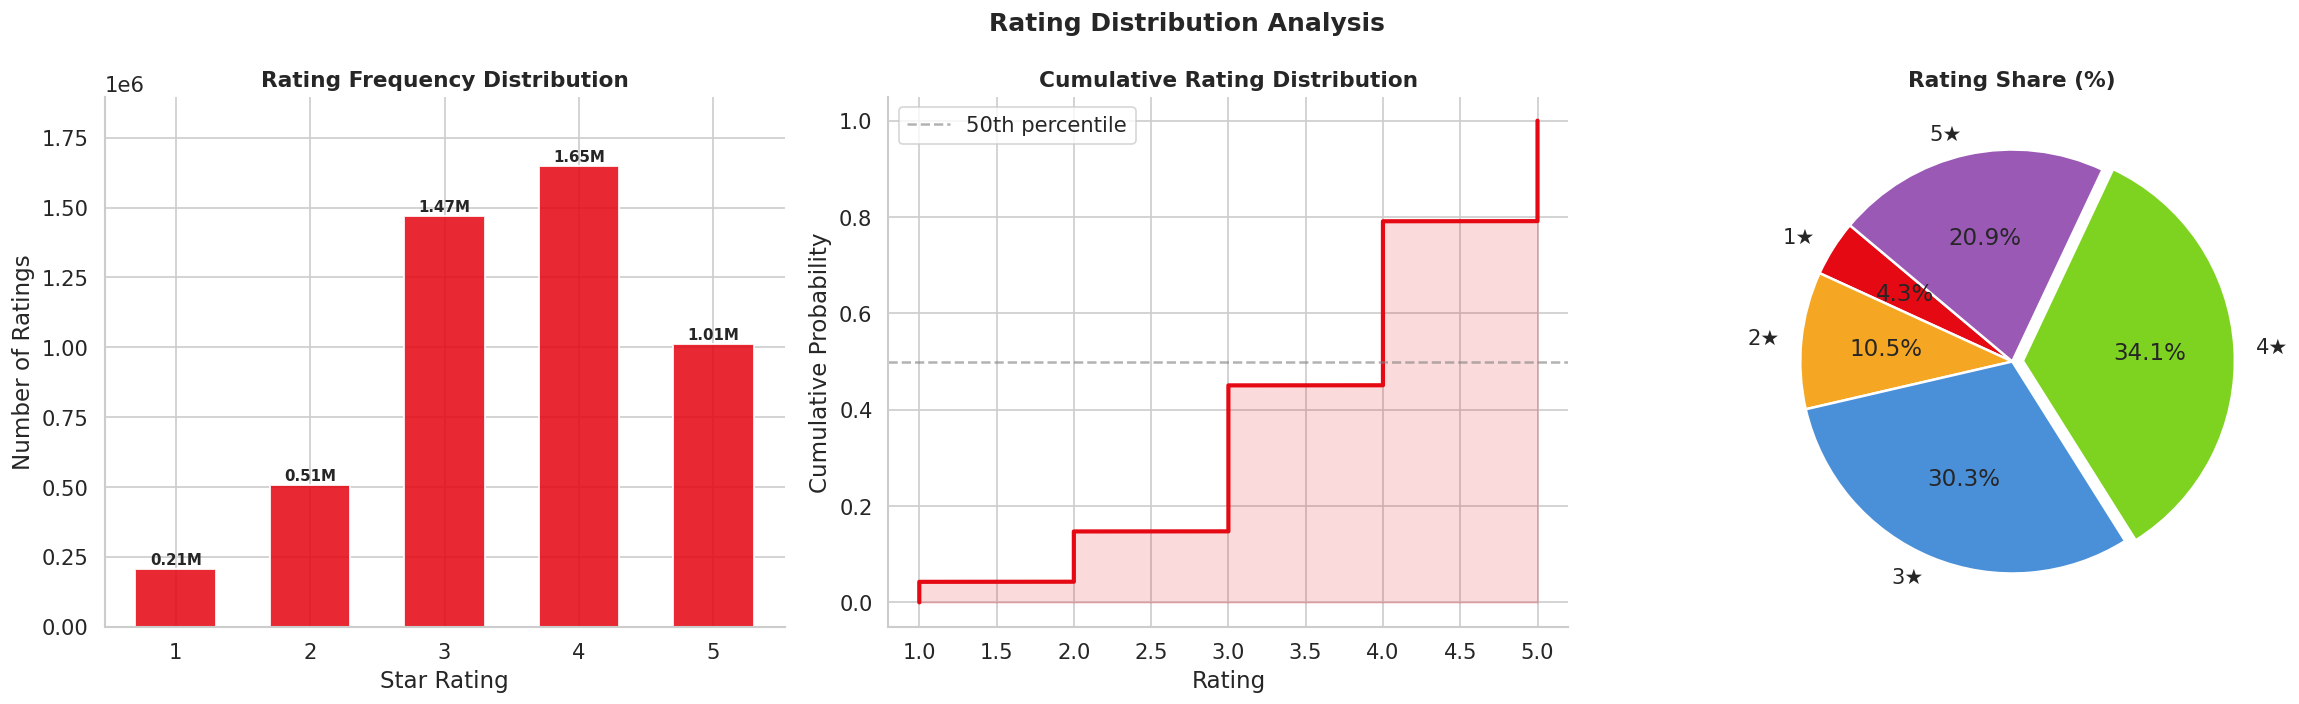


📊 KEY FINDINGS:
  Most common rating  : 4★ (34.1% of all ratings)
  Positive ratings ≥4 : 55.0%
  Negative ratings ≤2 : 14.7%
  Mean rating         : 3.568
  → Users tend to rate movies they chose to watch positively
    (selection bias — users self-select content they expect to enjoy)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Rating Distribution Analysis", fontsize=15, fontweight="bold")

# ── Panel 1: Raw rating frequency ─────────────────────────────────────────────
rating_counts = full_df["rating"].value_counts().sort_index()
bars = axes[0].bar(
    rating_counts.index, rating_counts.values,
    color=NETFLIX_RED, alpha=0.87, edgecolor="white", linewidth=1.2,
    width=0.6
)
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Ratings")
axes[0].set_title("Rating Frequency Distribution")
for bar, val in zip(bars, rating_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + rating_counts.max() * 0.01,
        f"{val/1e6:.2f}M", ha="center", fontsize=9, fontweight="bold"
    )
axes[0].set_ylim(0, rating_counts.max() * 1.15)

# ── Panel 2: Cumulative distribution ──────────────────────────────────────────
sorted_ratings = np.sort(full_df["rating"].values)
cdf = np.arange(1, len(sorted_ratings) + 1) / len(sorted_ratings)
axes[1].plot(sorted_ratings, cdf, color=NETFLIX_RED, linewidth=2.5)
axes[1].fill_between(sorted_ratings, cdf, alpha=0.15, color=NETFLIX_RED)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="50th percentile")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title("Cumulative Rating Distribution")
axes[1].legend()

# ── Panel 3: Rating share pie ─────────────────────────────────────────────────
labels    = [f"{r:.0f}★" for r in rating_counts.index]
explode   = [0.05 if r == 4.0 else 0 for r in rating_counts.index]
axes[2].pie(
    rating_counts.values, labels=labels,
    autopct="%1.1f%%", colors=PALETTE,
    explode=explode, startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[2].set_title("Rating Share (%)")

plt.tight_layout()
plt.savefig(OUT_DIR / "01_rating_distribution.png", dpi=150)
plt.show()

# Print key finding
mode_rating = rating_counts.idxmax()
pct_positive = (full_df["rating"] >= 4).mean() * 100
pct_negative = (full_df["rating"] <= 2).mean() * 100
print(f"\n📊 KEY FINDINGS:")
print(f"  Most common rating  : {mode_rating:.0f}★ "
      f"({rating_counts[mode_rating]/n_ratings*100:.1f}% of all ratings)")
print(f"  Positive ratings ≥4 : {pct_positive:.1f}%")
print(f"  Negative ratings ≤2 : {pct_negative:.1f}%")
print(f"  Mean rating         : {full_df['rating'].mean():.3f}")
print(f"  → Users tend to rate movies they chose to watch positively")
print(f"    (selection bias — users self-select content they expect to enjoy)")

## 4. User Activity Analysis

Understanding how active users are reveals the 
**long-tail distribution** — a small fraction of users 
generate the majority of ratings. This has direct 
implications for cold-start handling.

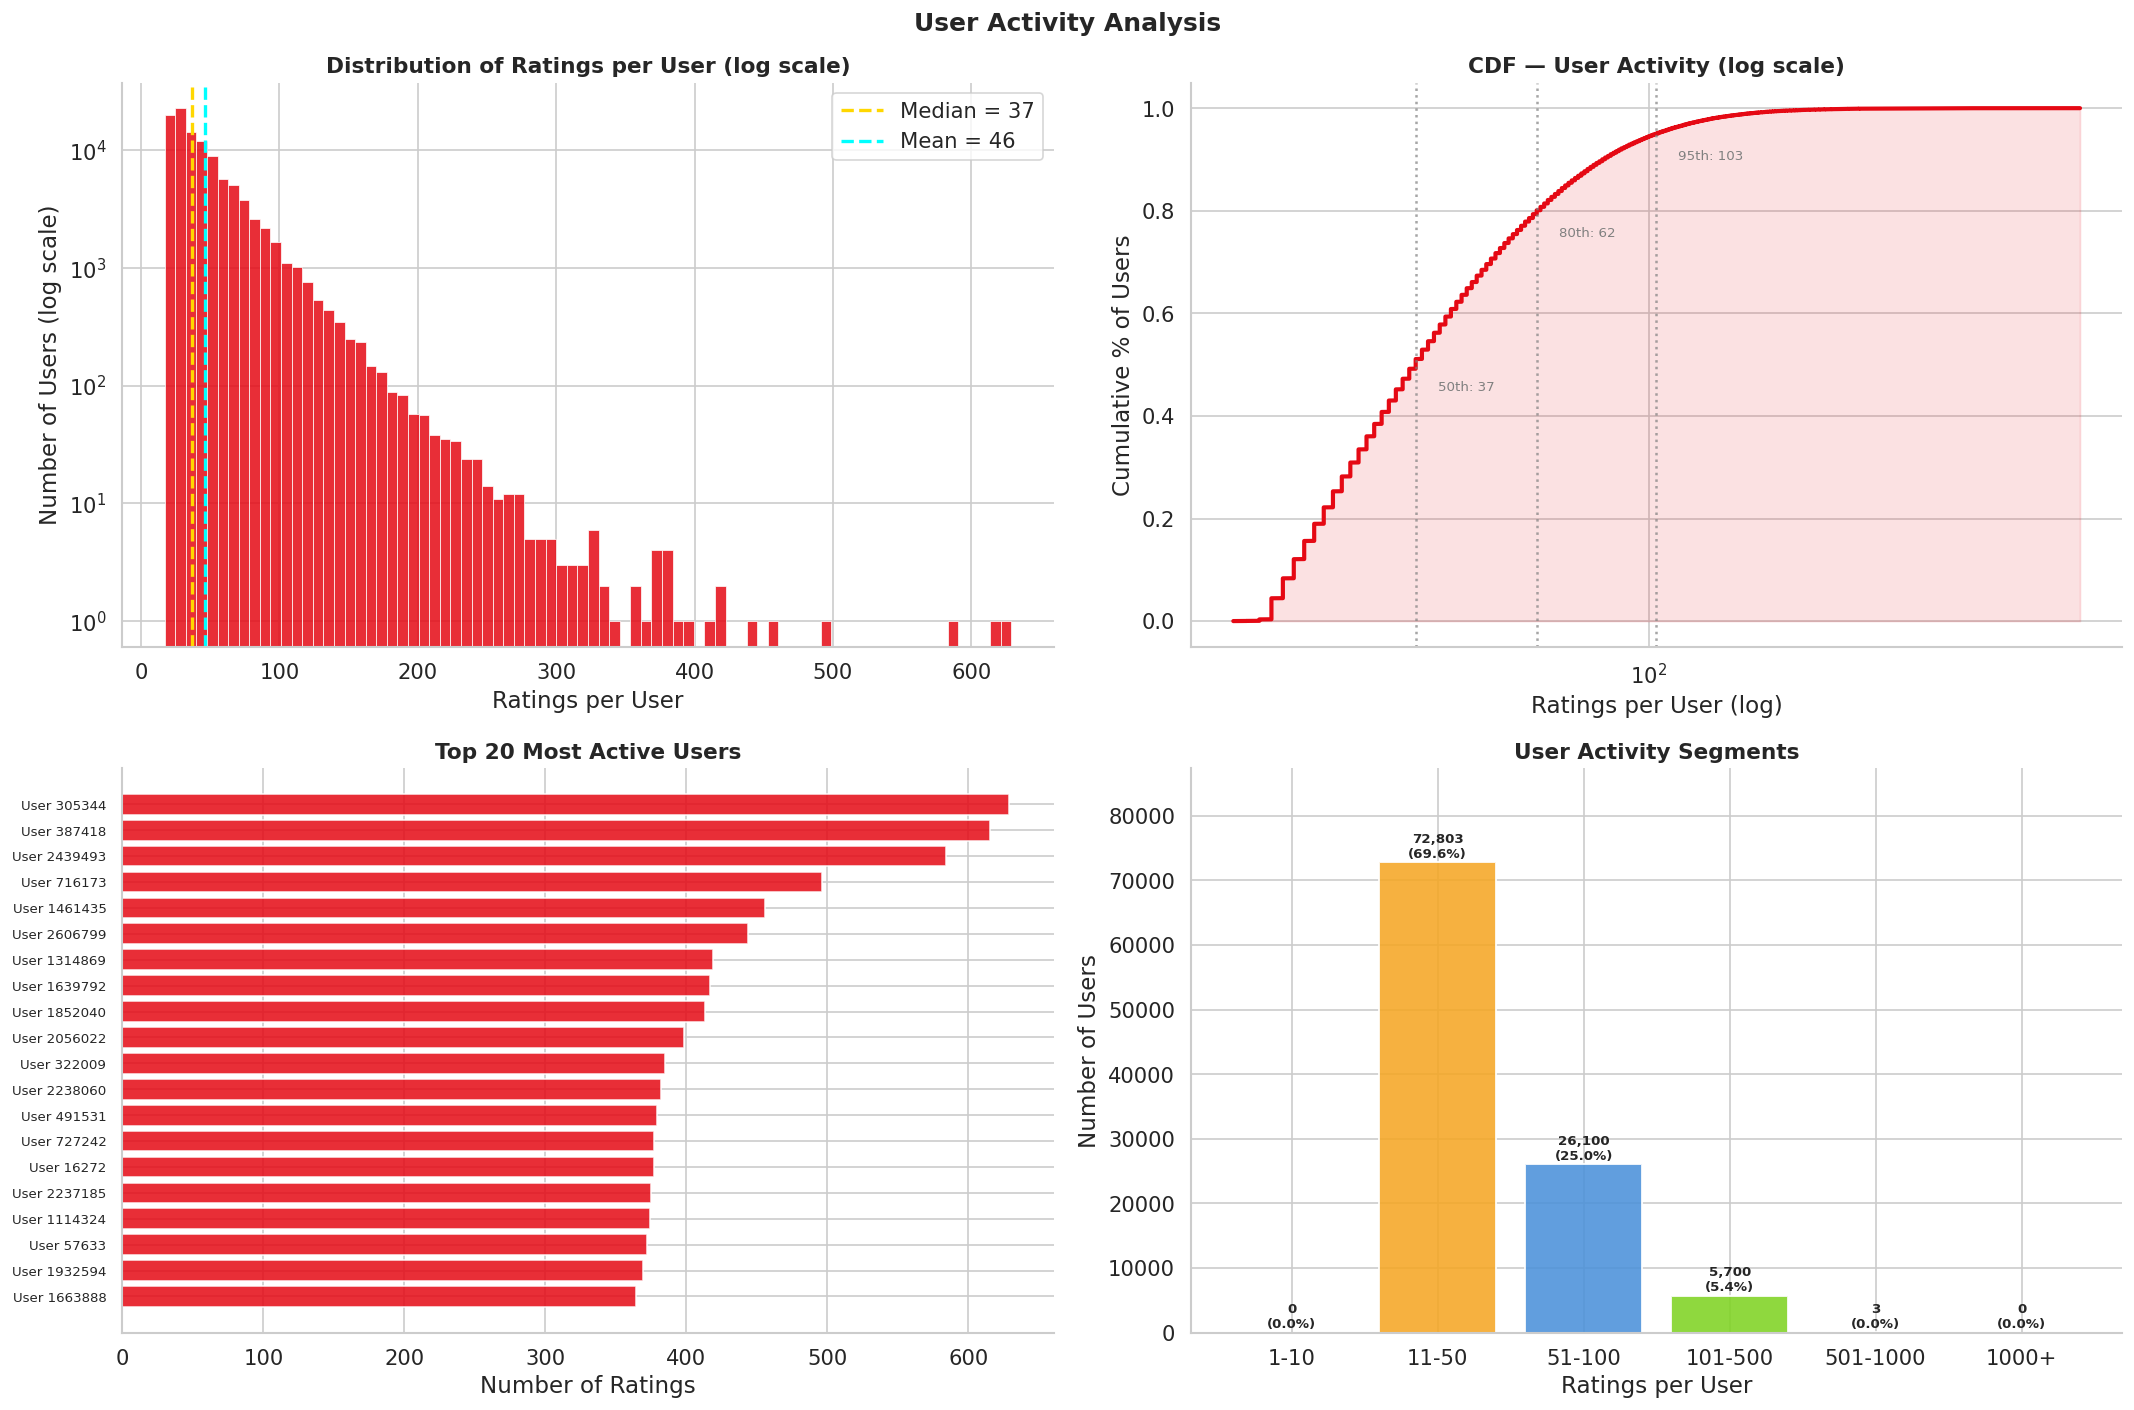


📊 KEY FINDINGS:
  Total users          : 104,606
  Median ratings/user  : 37
  Mean ratings/user    : 46
  Max ratings/user     : 629
  Min ratings/user     : 17
  Top 20% users        : generate 39.9% of all ratings
  → Classic Pareto distribution — power law user activity


In [5]:
ratings_per_user = full_df.groupby("user_id").size().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("User Activity Analysis", fontsize=15, fontweight="bold")

# ── Panel 1: Log histogram of ratings per user ────────────────────────────────
axes[0,0].hist(
    ratings_per_user.values, bins=80,
    color=NETFLIX_RED, alpha=0.85, edgecolor="white", linewidth=0.5,
    log=True
)
axes[0,0].set_xlabel("Ratings per User")
axes[0,0].set_ylabel("Number of Users (log scale)")
axes[0,0].set_title("Distribution of Ratings per User (log scale)")
axes[0,0].axvline(
    ratings_per_user.median(), color="gold",
    linestyle="--", linewidth=2,
    label=f"Median = {ratings_per_user.median():.0f}"
)
axes[0,0].axvline(
    ratings_per_user.mean(), color="cyan",
    linestyle="--", linewidth=2,
    label=f"Mean = {ratings_per_user.mean():.0f}"
)
axes[0,0].legend()

# ── Panel 2: CDF of user activity ────────────────────────────────────────────
sorted_u = np.sort(ratings_per_user.values)
cdf_u    = np.arange(1, len(sorted_u)+1) / len(sorted_u)
axes[0,1].plot(sorted_u, cdf_u, color=NETFLIX_RED, linewidth=2.5)
axes[0,1].fill_between(sorted_u, cdf_u, alpha=0.12, color=NETFLIX_RED)
axes[0,1].set_xscale("log")
axes[0,1].set_xlabel("Ratings per User (log)")
axes[0,1].set_ylabel("Cumulative % of Users")
axes[0,1].set_title("CDF — User Activity (log scale)")

# Annotate percentiles
for pct in [0.5, 0.8, 0.95]:
    idx  = int(pct * len(sorted_u))
    xval = sorted_u[idx]
    axes[0,1].axvline(xval, color="gray", linestyle=":", alpha=0.7)
    axes[0,1].text(
        xval * 1.1, pct - 0.05,
        f"{pct*100:.0f}th: {xval}", fontsize=8, color="gray"
    )

# ── Panel 3: Top-20 most active users ────────────────────────────────────────
top20_users = ratings_per_user.head(20)
axes[1,0].barh(
    range(20), top20_users.values[::-1],
    color=NETFLIX_RED, alpha=0.85, edgecolor="white"
)
axes[1,0].set_yticks(range(20))
axes[1,0].set_yticklabels(
    [f"User {uid}" for uid in top20_users.index[::-1]],
    fontsize=8
)
axes[1,0].set_xlabel("Number of Ratings")
axes[1,0].set_title("Top 20 Most Active Users")

# ── Panel 4: User activity buckets ───────────────────────────────────────────
buckets = pd.cut(
    ratings_per_user,
    bins=[0, 10, 50, 100, 500, 1000, float("inf")],
    labels=["1-10", "11-50", "51-100", "101-500", "501-1000", "1000+"]
)
bucket_counts = buckets.value_counts().sort_index()
bars = axes[1,1].bar(
    bucket_counts.index, bucket_counts.values,
    color=PALETTE[:len(bucket_counts)],
    alpha=0.87, edgecolor="white", linewidth=1.2
)
axes[1,1].set_xlabel("Ratings per User")
axes[1,1].set_ylabel("Number of Users")
axes[1,1].set_title("User Activity Segments")
for bar, val in zip(bars, bucket_counts.values):
    pct = val / len(ratings_per_user) * 100
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + bucket_counts.max() * 0.01,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", fontsize=8, fontweight="bold"
    )
axes[1,1].set_ylim(0, bucket_counts.max() * 1.2)

plt.tight_layout()
plt.savefig(OUT_DIR / "02_user_activity.png", dpi=150)
plt.show()

# Key stats
p80_users = (ratings_per_user > ratings_per_user.quantile(0.8)).sum()
p80_ratings = ratings_per_user[ratings_per_user > ratings_per_user.quantile(0.8)].sum()
print(f"\n📊 KEY FINDINGS:")
print(f"  Total users          : {len(ratings_per_user):,}")
print(f"  Median ratings/user  : {ratings_per_user.median():.0f}")
print(f"  Mean ratings/user    : {ratings_per_user.mean():.0f}")
print(f"  Max ratings/user     : {ratings_per_user.max():,}")
print(f"  Min ratings/user     : {ratings_per_user.min():,}")
print(f"  Top 20% users        : generate "
      f"{p80_ratings/n_ratings*100:.1f}% of all ratings")
print(f"  → Classic Pareto distribution — power law user activity")

## 5. Content Popularity Analysis

Movie popularity follows an extreme long-tail distribution.
A small number of blockbusters receive the vast majority 
of ratings, while most movies are rarely rated.
This directly causes **popularity bias** in recommendation systems.

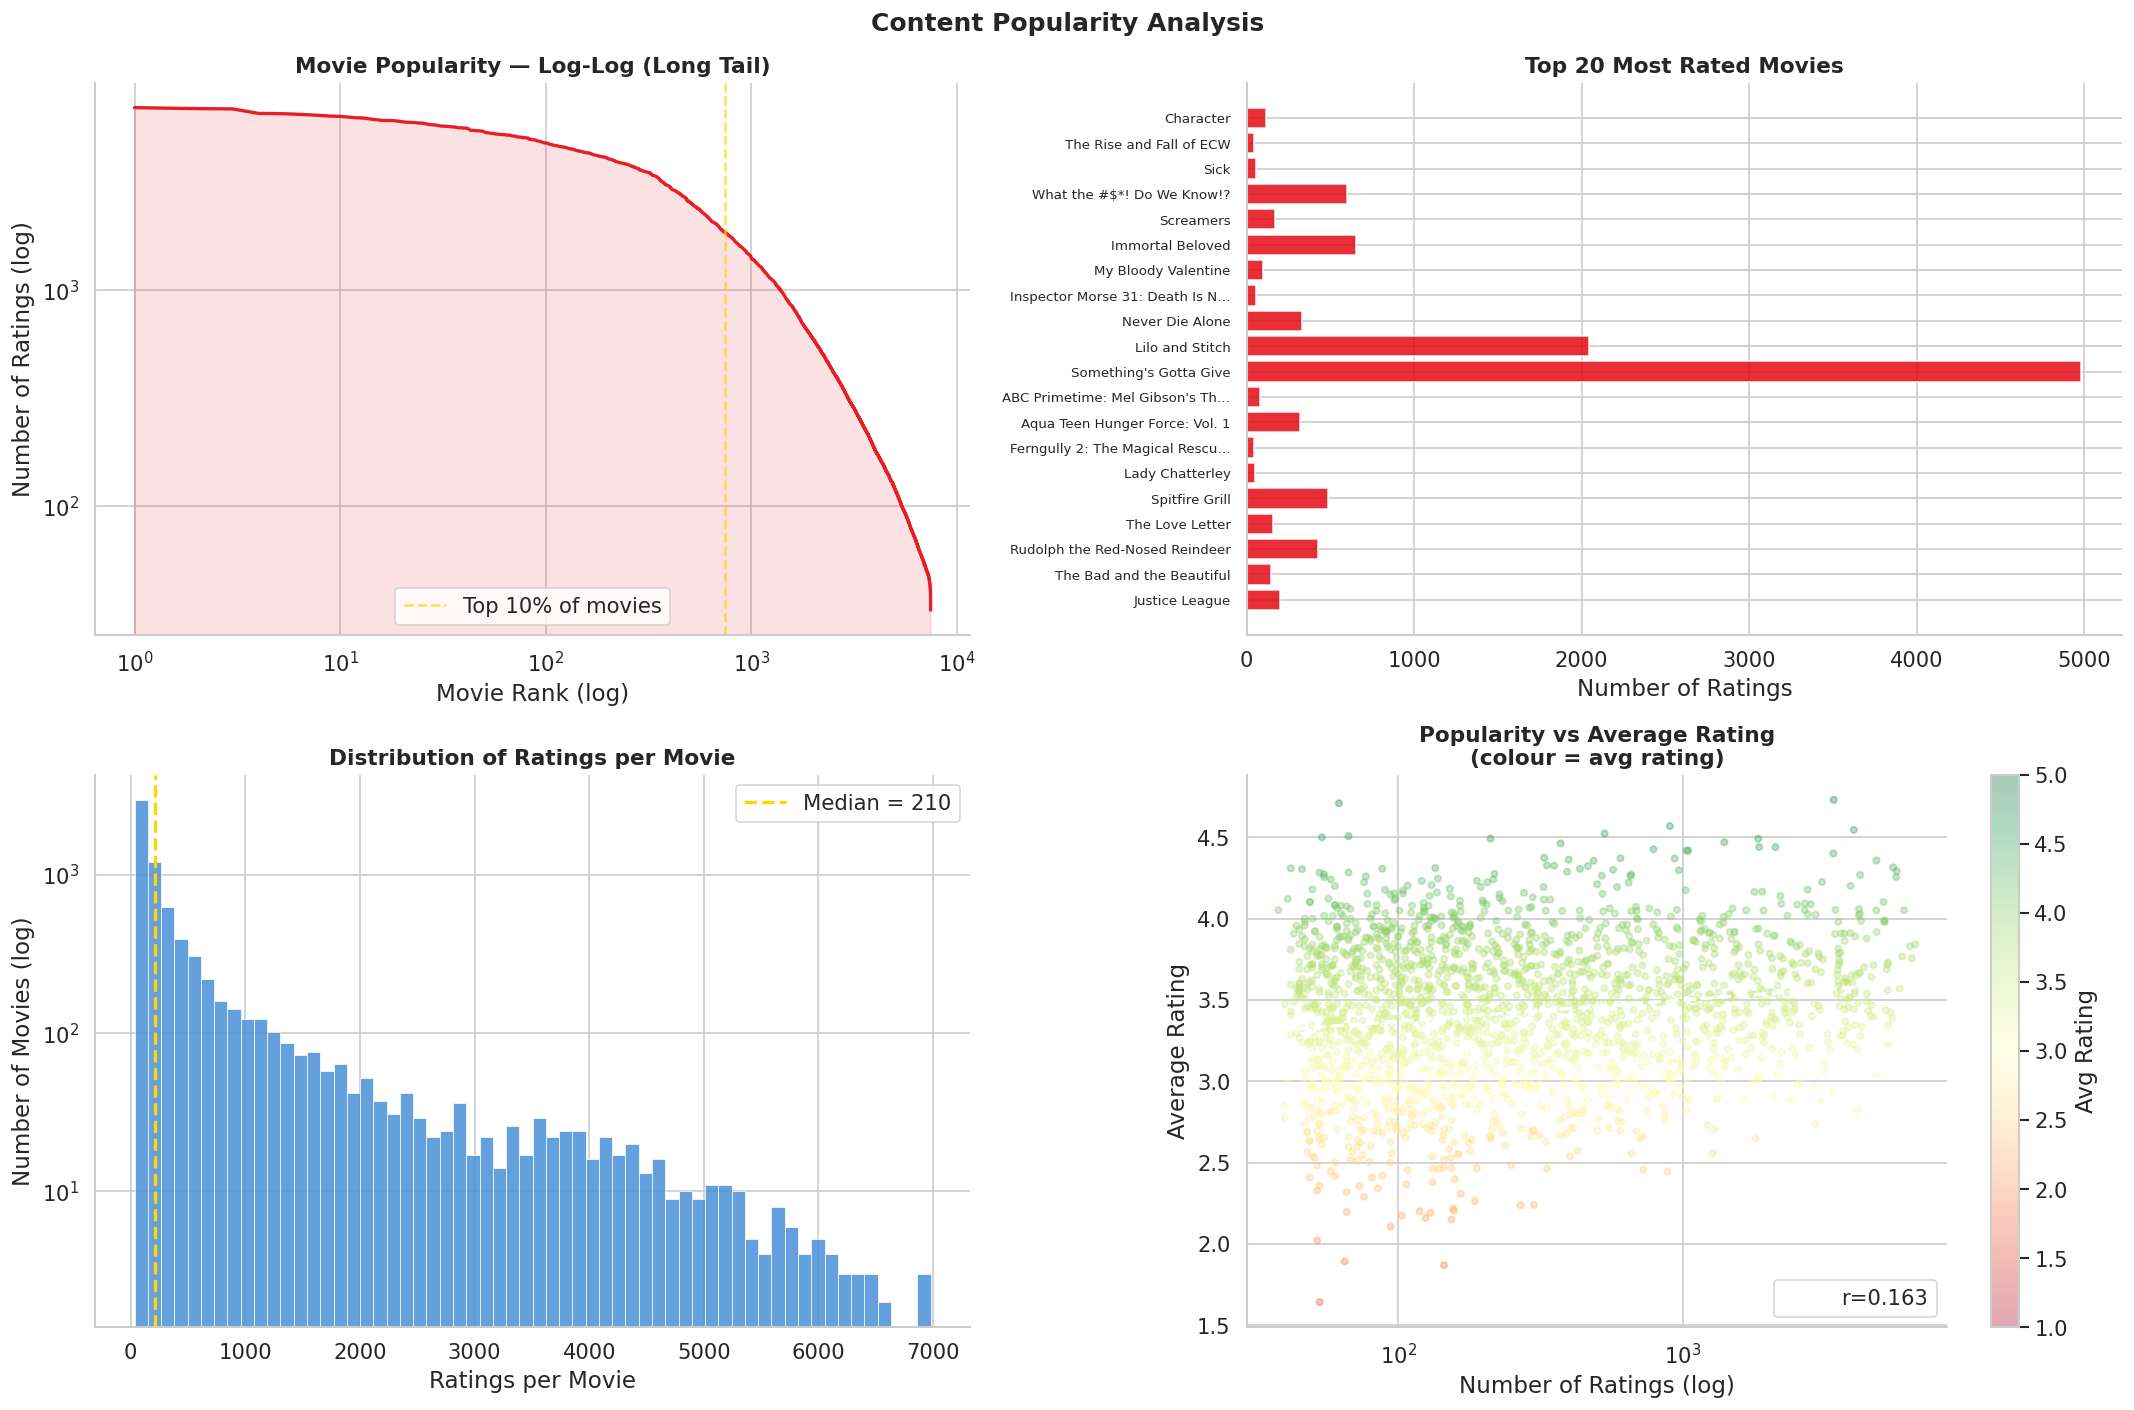


📊 KEY FINDINGS:
  Total movies           : 7,441
  Most rated movie       : Character (6,979 ratings)
  Median ratings/movie   : 210
  Movies with <10 ratings: 0 (0.0%)
  Top 10% movies generate: 51.7% of all ratings
  Popularity-Rating corr : r=0.163 (positive — popular films rated higher)


In [6]:
ratings_per_movie = full_df.groupby("movie_id").size().sort_values(ascending=False)
avg_rating_movie  = full_df.groupby("movie_id")["rating"].mean()
movie_stats = pd.DataFrame({
    "n_ratings"  : ratings_per_movie,
    "avg_rating" : avg_rating_movie,
}).join(movies.set_index("movie_id")[["title","year"]])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Content Popularity Analysis", fontsize=15, fontweight="bold")

# ── Panel 1: Log-log rank vs popularity ──────────────────────────────────────
counts = ratings_per_movie.values
axes[0,0].plot(
    range(1, len(counts)+1), counts,
    color=NETFLIX_RED, linewidth=2, alpha=0.9
)
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")
axes[0,0].set_xlabel("Movie Rank (log)")
axes[0,0].set_ylabel("Number of Ratings (log)")
axes[0,0].set_title("Movie Popularity — Log-Log (Long Tail)")
axes[0,0].fill_between(
    range(1, len(counts)+1), counts,
    alpha=0.12, color=NETFLIX_RED
)
axes[0,0].axvline(len(counts)*0.1, color="gold",
                   linestyle="--", alpha=0.7,
                   label="Top 10% of movies")
axes[0,0].legend()

# ── Panel 2: Top 20 most rated movies ────────────────────────────────────────
top20 = movie_stats.head(20)
titles_short = [
    (t[:30] + "…" if len(t) > 30 else t)
    for t in top20["title"].fillna(f"Movie {top20.index}")
]
axes[0,1].barh(
    range(20), top20["n_ratings"].values[::-1],
    color=NETFLIX_RED, alpha=0.85, edgecolor="white"
)
axes[0,1].set_yticks(range(20))
axes[0,1].set_yticklabels(titles_short[::-1], fontsize=8)
axes[0,1].set_xlabel("Number of Ratings")
axes[0,1].set_title("Top 20 Most Rated Movies")

# ── Panel 3: Rating count distribution ───────────────────────────────────────
axes[1,0].hist(
    ratings_per_movie.values, bins=60,
    color="#4A90D9", alpha=0.85,
    edgecolor="white", linewidth=0.5, log=True
)
axes[1,0].set_xlabel("Ratings per Movie")
axes[1,0].set_ylabel("Number of Movies (log)")
axes[1,0].set_title("Distribution of Ratings per Movie")
axes[1,0].axvline(
    ratings_per_movie.median(), color="gold",
    linestyle="--", linewidth=2,
    label=f"Median = {ratings_per_movie.median():.0f}"
)
axes[1,0].legend()

# ── Panel 4: Popularity vs Average Rating scatter ────────────────────────────
sample = movie_stats.sample(min(2000, len(movie_stats)), random_state=42)
sc = axes[1,1].scatter(
    sample["n_ratings"], sample["avg_rating"],
    alpha=0.35, s=15,
    c=sample["avg_rating"], cmap="RdYlGn",
    vmin=1, vmax=5
)
axes[1,1].set_xscale("log")
axes[1,1].set_xlabel("Number of Ratings (log)")
axes[1,1].set_ylabel("Average Rating")
axes[1,1].set_title("Popularity vs Average Rating\n(colour = avg rating)")
plt.colorbar(sc, ax=axes[1,1], label="Avg Rating")

# Regression line
log_x = np.log10(sample["n_ratings"])
slope, intercept, r, p, _ = stats.linregress(log_x, sample["avg_rating"])
x_range = np.linspace(log_x.min(), log_x.max(), 100)
axes[1,1].plot(
    10**x_range, intercept + slope * x_range,
    color="white", linewidth=2, linestyle="--",
    label=f"r={r:.3f}"
)
axes[1,1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "03_content_popularity.png", dpi=150)
plt.show()

top10_pct_movies  = len(counts) * 0.1
top10_pct_ratings = ratings_per_movie.head(int(top10_pct_movies)).sum()
print(f"\n📊 KEY FINDINGS:")
print(f"  Total movies           : {len(ratings_per_movie):,}")
print(f"  Most rated movie       : {movie_stats['title'].iloc[0]} "
      f"({ratings_per_movie.iloc[0]:,} ratings)")
print(f"  Median ratings/movie   : {ratings_per_movie.median():.0f}")
print(f"  Movies with <10 ratings: "
      f"{(ratings_per_movie < 10).sum():,} "
      f"({(ratings_per_movie < 10).mean()*100:.1f}%)")
print(f"  Top 10% movies generate: "
      f"{top10_pct_ratings/n_ratings*100:.1f}% of all ratings")
print(f"  Popularity-Rating corr : r={r:.3f} "
      f"({'positive' if r > 0 else 'negative'} — "
      f"{'popular films rated higher' if r > 0 else 'niche films rated higher'})")

## 6. Temporal Analysis

Analysing rating patterns over time reveals:
- Dataset time coverage
- Rating volume trends  
- Whether user behaviour changed over time
- Seasonal patterns

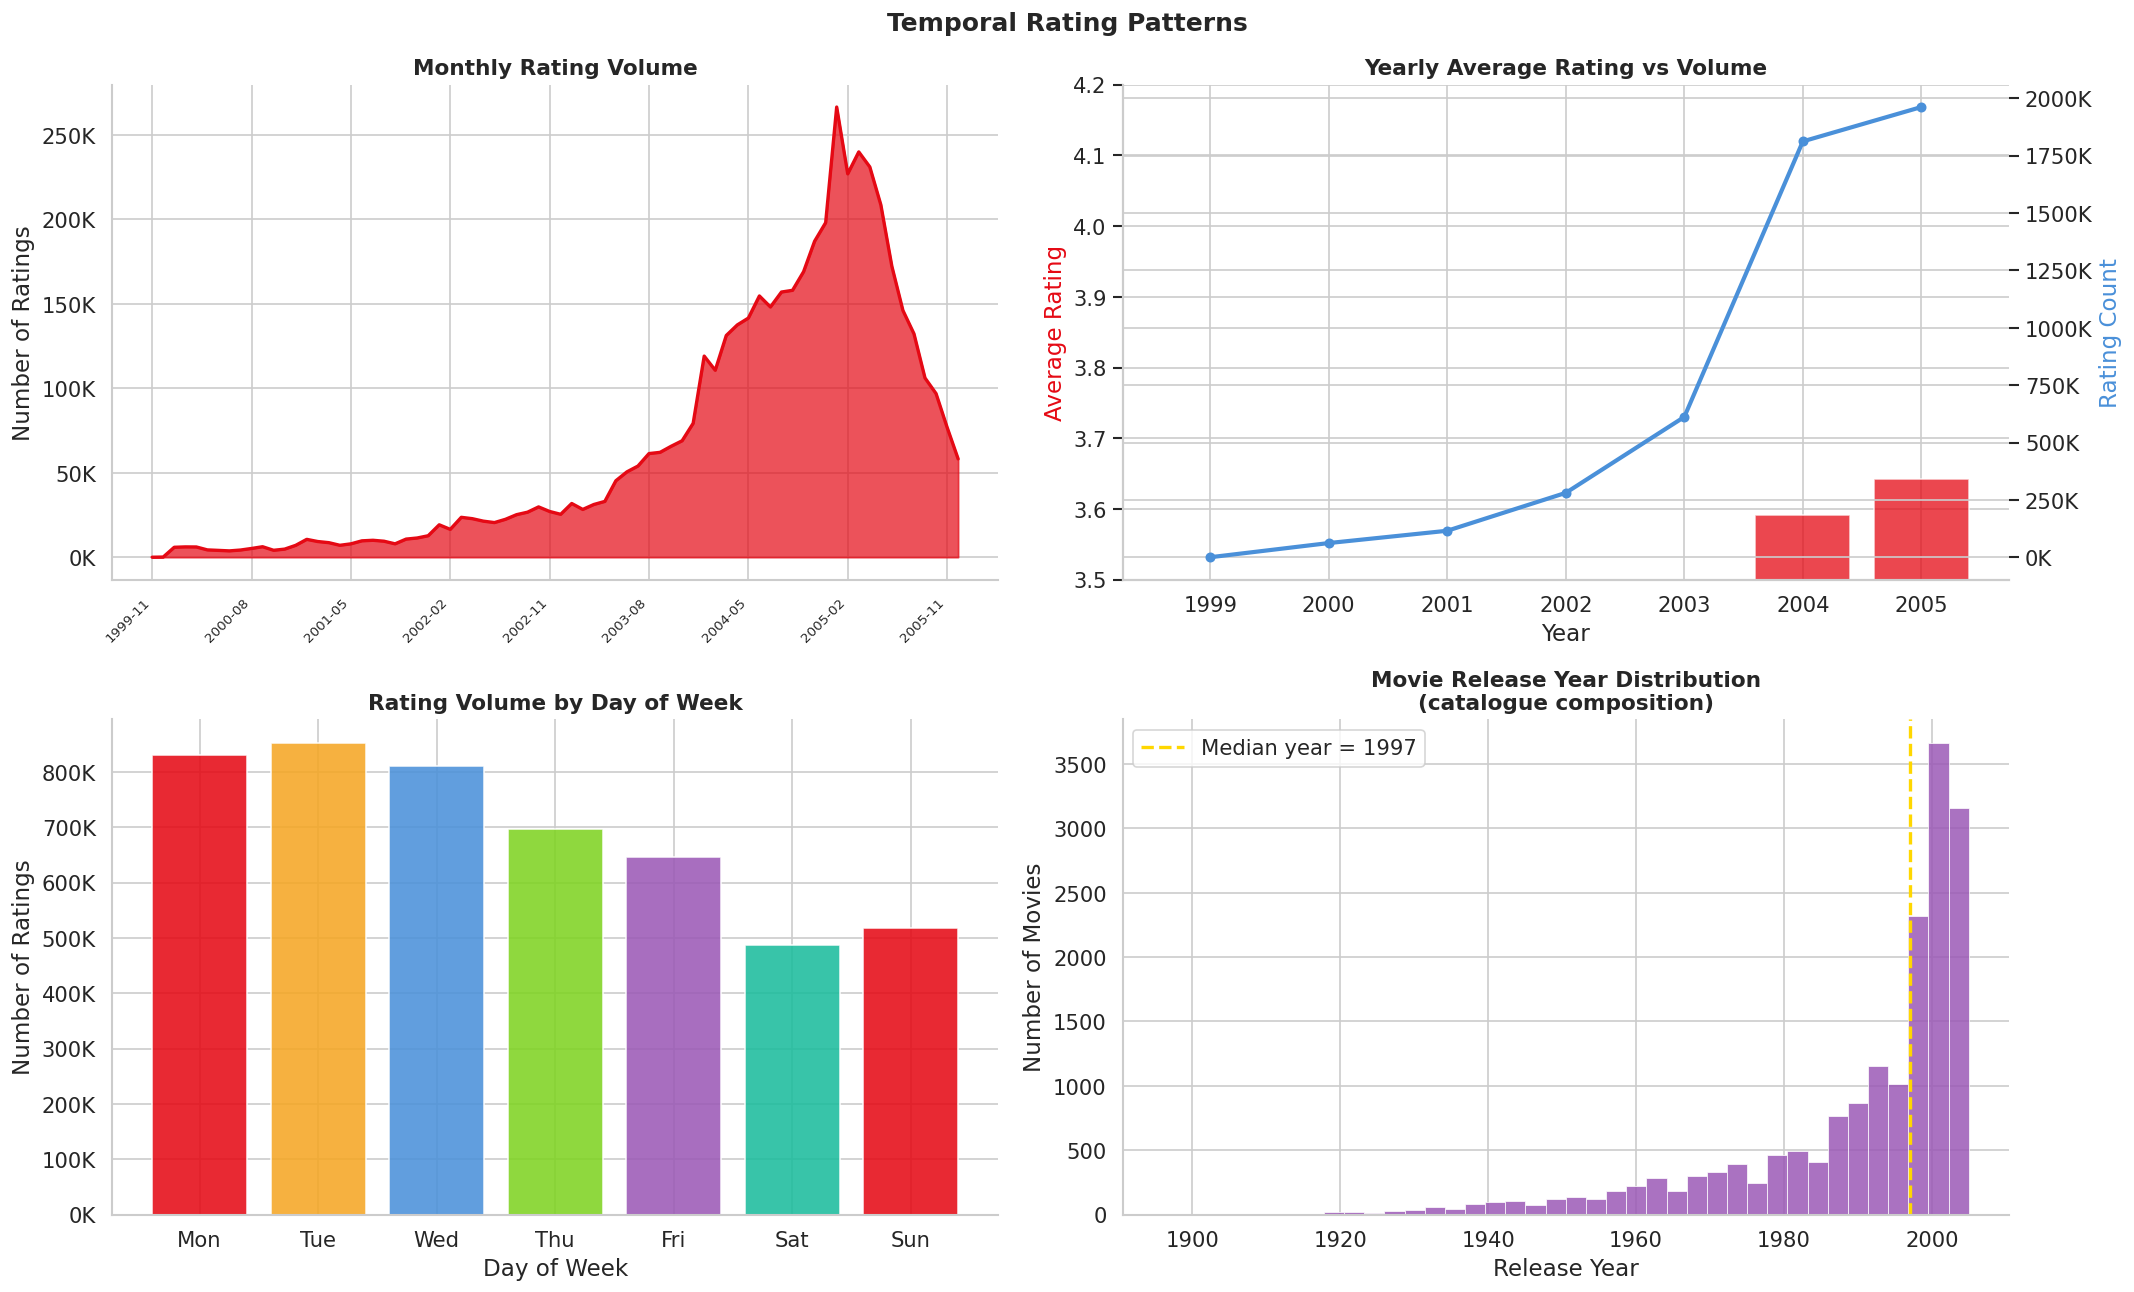


📊 KEY FINDINGS:
  Dataset spans        : 1999-11-11 → 2005-12-31
  Peak rating month    : 2005-01 (266,532 ratings)
  Busiest day          : Tue (852,909 ratings)
  Movie release range  : 1896 – 2005
  Median release year  : 1997


In [7]:
full_df["year_month"] = full_df["date"].dt.to_period("M")
full_df["year_only"]  = full_df["date"].dt.year
full_df["month_only"] = full_df["date"].dt.month
full_df["dayofweek"]  = full_df["date"].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle("Temporal Rating Patterns", fontsize=15, fontweight="bold")

# ── Panel 1: Ratings per month ────────────────────────────────────────────────
monthly = full_df.groupby("year_month").size()
monthly_idx = [str(p) for p in monthly.index]
axes[0,0].fill_between(
    range(len(monthly)), monthly.values,
    color=NETFLIX_RED, alpha=0.7
)
axes[0,0].plot(
    range(len(monthly)), monthly.values,
    color=NETFLIX_RED, linewidth=2
)
tick_step = max(1, len(monthly) // 8)
axes[0,0].set_xticks(range(0, len(monthly), tick_step))
axes[0,0].set_xticklabels(
    monthly_idx[::tick_step], rotation=45, ha="right", fontsize=8
)
axes[0,0].set_ylabel("Number of Ratings")
axes[0,0].set_title("Monthly Rating Volume")
axes[0,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K")
)

# ── Panel 2: Average rating per year ─────────────────────────────────────────
yearly_avg = full_df.groupby("year_only")["rating"].agg(["mean","count"])
ax_twin    = axes[0,1].twinx()
axes[0,1].bar(
    yearly_avg.index, yearly_avg["mean"],
    color=NETFLIX_RED, alpha=0.75,
    edgecolor="white", linewidth=1
)
ax_twin.plot(
    yearly_avg.index, yearly_avg["count"],
    color="#4A90D9", linewidth=2.5,
    marker="o", markersize=5, label="Rating Count"
)
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Average Rating", color=NETFLIX_RED)
ax_twin.set_ylabel("Rating Count", color="#4A90D9")
axes[0,1].set_title("Yearly Average Rating vs Volume")
axes[0,1].set_ylim(3.5, 4.2)
ax_twin.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K")
)

# ── Panel 3: Day of week pattern ─────────────────────────────────────────────
dow_counts = full_df.groupby("dayofweek").size()
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
axes[1,0].bar(
    dow_labels, dow_counts.values,
    color=PALETTE, alpha=0.87, edgecolor="white"
)
axes[1,0].set_xlabel("Day of Week")
axes[1,0].set_ylabel("Number of Ratings")
axes[1,0].set_title("Rating Volume by Day of Week")
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K")
)

# ── Panel 4: Movie release year distribution ──────────────────────────────────
movie_years = movies["year"].dropna()
axes[1,1].hist(
    movie_years, bins=40,
    color="#9B59B6", alpha=0.85,
    edgecolor="white", linewidth=0.5
)
axes[1,1].set_xlabel("Release Year")
axes[1,1].set_ylabel("Number of Movies")
axes[1,1].set_title("Movie Release Year Distribution\n(catalogue composition)")
axes[1,1].axvline(
    movie_years.median(), color="gold",
    linestyle="--", linewidth=2,
    label=f"Median year = {movie_years.median():.0f}"
)
axes[1,1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "04_temporal_analysis.png", dpi=150)
plt.show()

print(f"\n📊 KEY FINDINGS:")
print(f"  Dataset spans        : {full_df['date'].min().date()} → "
      f"{full_df['date'].max().date()}")
print(f"  Peak rating month    : {monthly.idxmax()} "
      f"({monthly.max():,} ratings)")
print(f"  Busiest day          : {dow_labels[dow_counts.idxmax()]} "
      f"({dow_counts.max():,} ratings)")
print(f"  Movie release range  : {movie_years.min():.0f} – "
      f"{movie_years.max():.0f}")
print(f"  Median release year  : {movie_years.median():.0f}")

## 7. Data Sparsity Analysis

The user-item matrix is the core data structure of collaborative filtering.
Visualising its sparsity reveals why matrix factorization methods 
are necessary — direct similarity computation is infeasible.

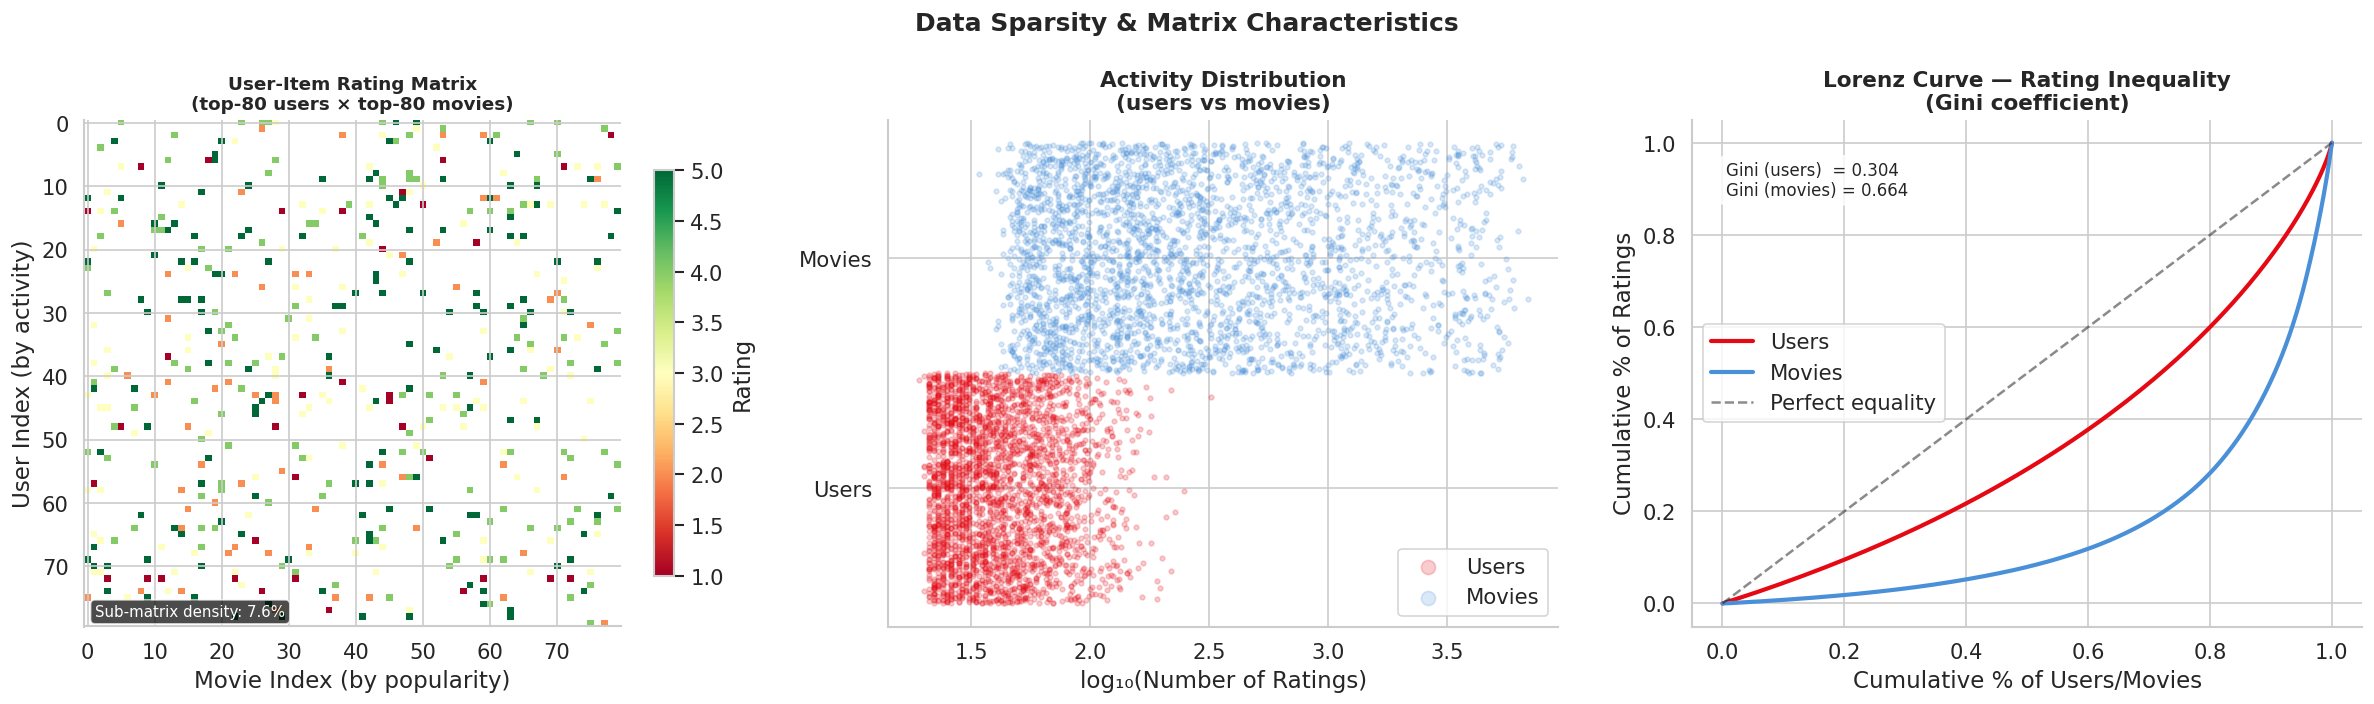


📊 KEY FINDINGS:
  Matrix density      : 0.622285%
  Gini — users        : 0.3038 (1=max inequality)
  Gini — movies       : 0.6637
  → Extreme inequality in both users and movies
  → Justifies collaborative filtering over content-based approaches
  → Cold-start problem is severe for new users/items


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Data Sparsity & Matrix Characteristics", 
             fontsize=15, fontweight="bold")

# ── Panel 1: Sparsity visualisation (sampled submatrix) ───────────────────────
sample_users  = full_df["user_id"].value_counts().head(80).index
sample_movies = full_df["movie_id"].value_counts().head(80).index
sub = full_df[
    full_df["user_id"].isin(sample_users) &
    full_df["movie_id"].isin(sample_movies)
].pivot_table(
    index="user_id", columns="movie_id",
    values="rating", aggfunc="mean"
)
im = axes[0].imshow(
    sub.values, aspect="auto",
    cmap="RdYlGn", vmin=1, vmax=5,
    interpolation="nearest"
)
axes[0].set_title(
    "User-Item Rating Matrix\n(top-80 users × top-80 movies)",
    fontsize=11
)
axes[0].set_xlabel("Movie Index (by popularity)")
axes[0].set_ylabel("User Index (by activity)")
plt.colorbar(im, ax=axes[0], label="Rating", shrink=0.8)
sub_density = sub.notna().mean().mean()
axes[0].text(
    0.02, 0.02,
    f"Sub-matrix density: {sub_density:.1%}",
    transform=axes[0].transAxes,
    color="white", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.7)
)

# ── Panel 2: Ratings per user vs ratings per movie (scatter) ─────────────────
user_counts  = full_df.groupby("user_id").size()
movie_counts = full_df.groupby("movie_id").size()

np.random.seed(42)
u_sample = user_counts.sample(min(3000, len(user_counts)))
m_sample = movie_counts.sample(min(3000, len(movie_counts)))

axes[1].scatter(
    np.log10(u_sample.values + 1),
    np.random.uniform(0, 1, len(u_sample)),
    alpha=0.2, s=8, color=NETFLIX_RED, label="Users"
)
axes[1].scatter(
    np.log10(m_sample.values + 1),
    np.random.uniform(1, 2, len(m_sample)),
    alpha=0.2, s=8, color="#4A90D9", label="Movies"
)
axes[1].set_xlabel("log₁₀(Number of Ratings)")
axes[1].set_yticks([0.5, 1.5])
axes[1].set_yticklabels(["Users", "Movies"])
axes[1].set_title("Activity Distribution\n(users vs movies)")
axes[1].legend(markerscale=3)

# ── Panel 3: Gini coefficient visualisation ───────────────────────────────────
for label, counts_arr, color in [
    ("Users",  np.sort(user_counts.values),  NETFLIX_RED),
    ("Movies", np.sort(movie_counts.values), "#4A90D9"),
]:
    n    = len(counts_arr)
    cum  = np.cumsum(counts_arr) / counts_arr.sum()
    pop  = np.arange(1, n+1) / n
    axes[2].plot(pop, cum, linewidth=2.5, label=label, color=color)

axes[2].plot([0,1],[0,1], "k--", linewidth=1.5,
             alpha=0.5, label="Perfect equality")
axes[2].fill_between([0,1],[0,1],[0,1], alpha=0.05, color="gray")
axes[2].set_xlabel("Cumulative % of Users/Movies")
axes[2].set_ylabel("Cumulative % of Ratings")
axes[2].set_title("Lorenz Curve — Rating Inequality\n(Gini coefficient)")
axes[2].legend()

# Compute Gini
def gini(arr):
    arr  = np.sort(arr)
    n    = len(arr)
    idx  = np.arange(1, n+1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n+1)/n

g_users  = gini(user_counts.values)
g_movies = gini(movie_counts.values)
axes[2].text(
    0.05, 0.85,
    f"Gini (users)  = {g_users:.3f}\n"
    f"Gini (movies) = {g_movies:.3f}",
    transform=axes[2].transAxes, fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(OUT_DIR / "05_sparsity_analysis.png", dpi=150)
plt.show()

print(f"\n📊 KEY FINDINGS:")
print(f"  Matrix density      : {density:.6%}")
print(f"  Gini — users        : {g_users:.4f} (1=max inequality)")
print(f"  Gini — movies       : {g_movies:.4f}")
print(f"  → Extreme inequality in both users and movies")
print(f"  → Justifies collaborative filtering over content-based approaches")
print(f"  → Cold-start problem is severe for new users/items")

## 8. User-Item Interaction Patterns

Cross-analysis of user behaviour and content characteristics
to understand rating patterns and identify power users / blockbusters.

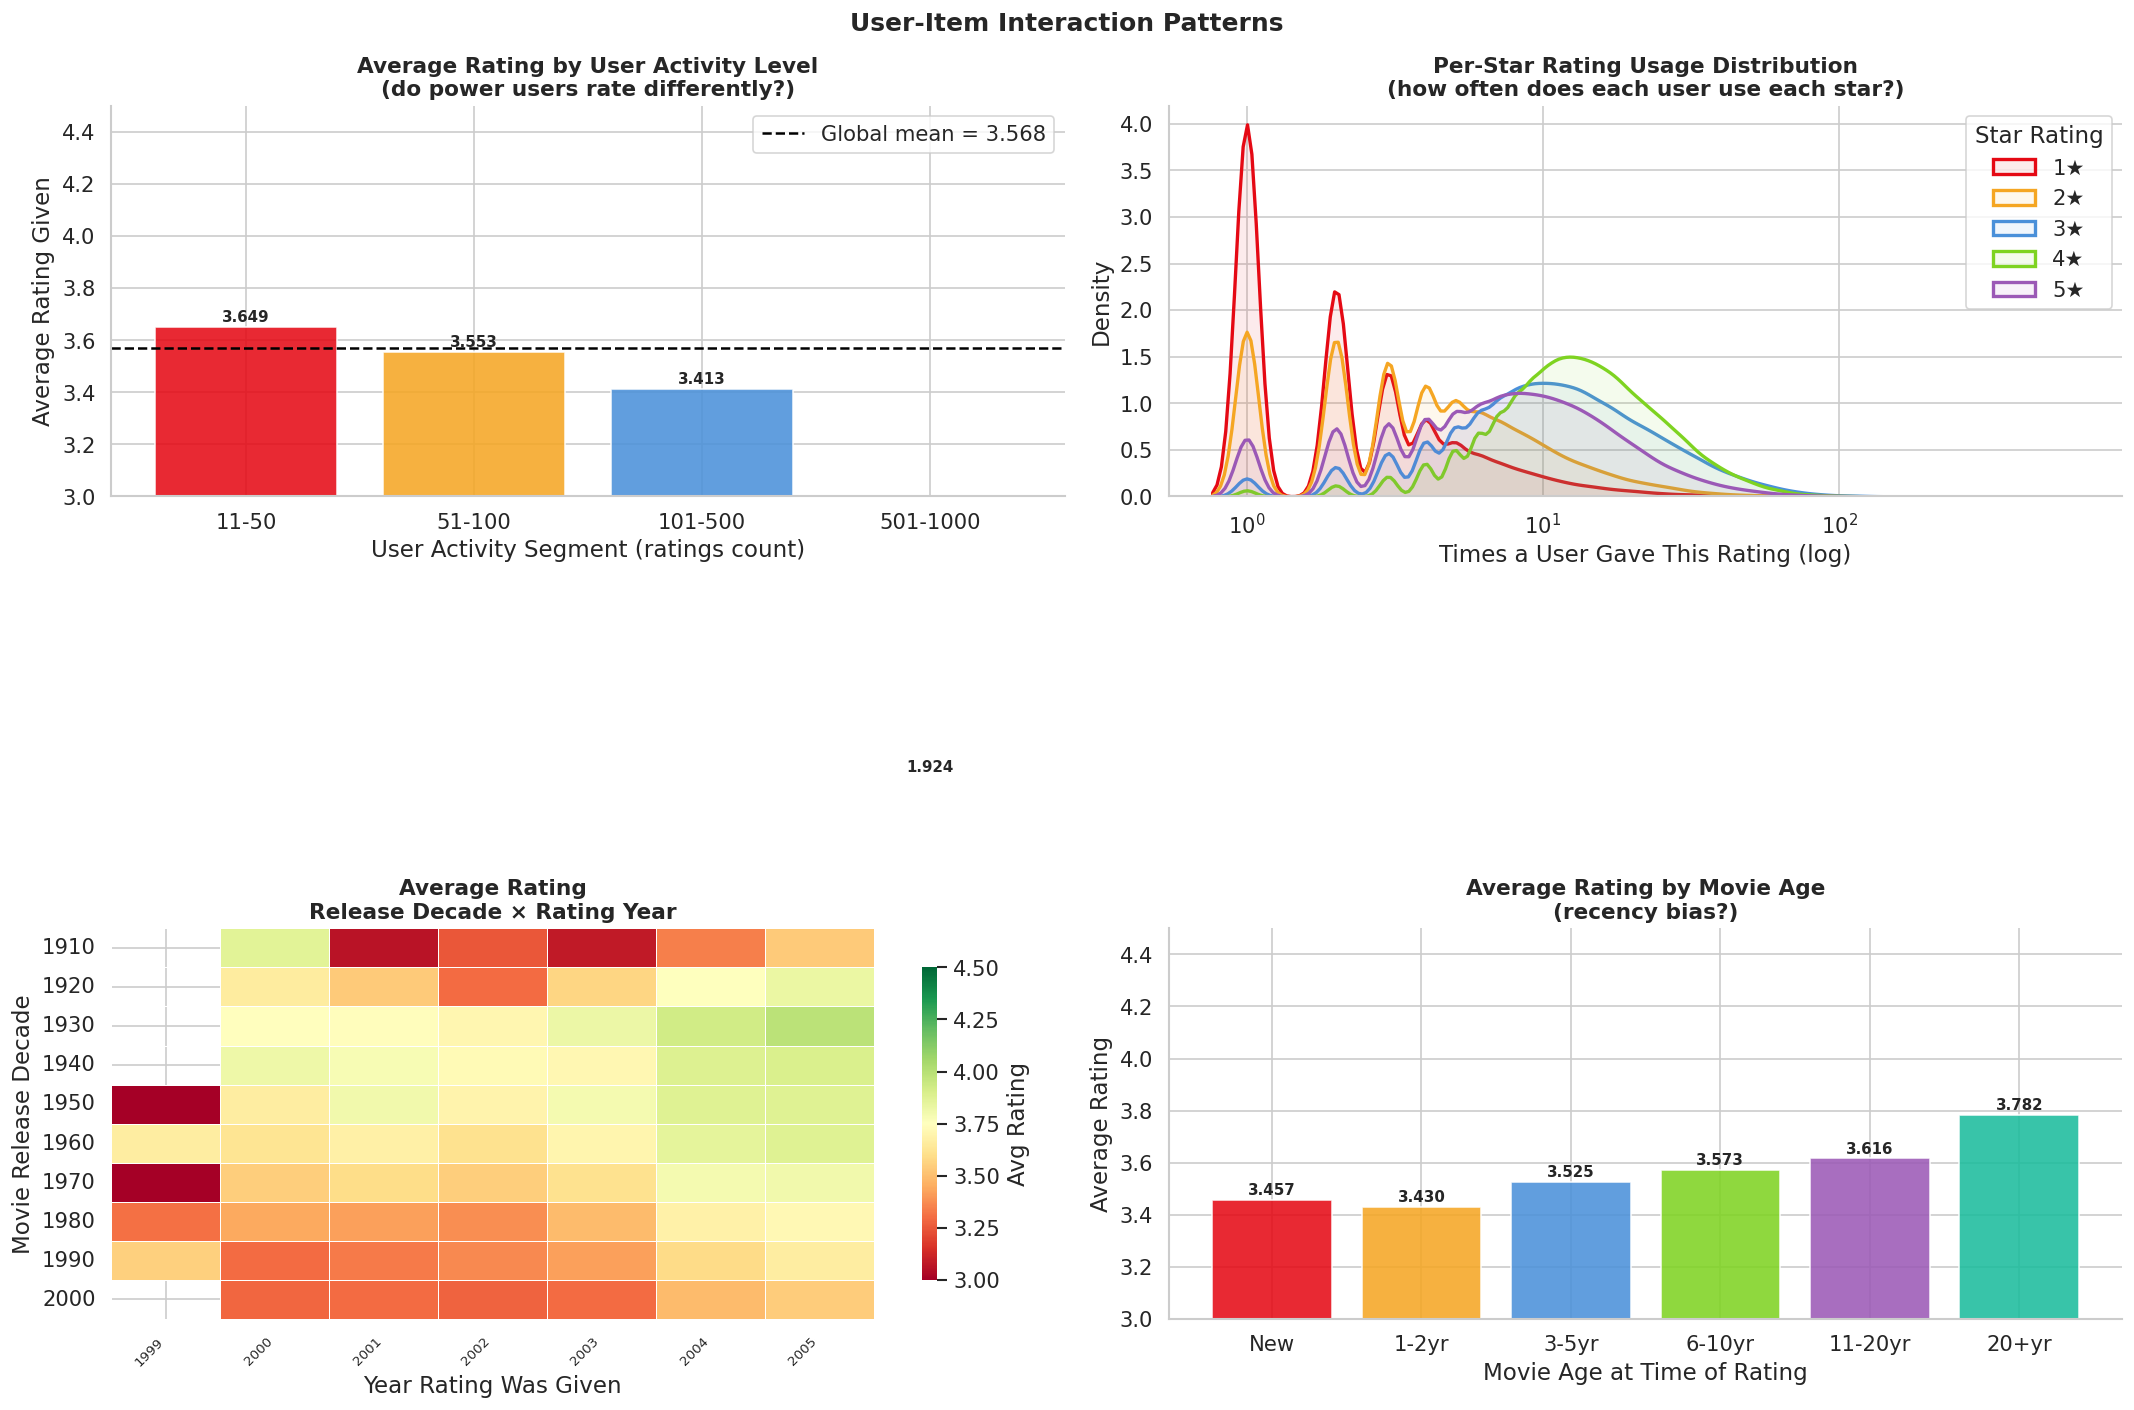


📊 KEY FINDINGS:
  Global mean rating  : 3.5684
  Power users (1000+) avg rating: nan
  Casual users (1-10) avg rating: nan


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("User-Item Interaction Patterns", fontsize=15, fontweight="bold")

# ── Panel 1: Average rating by user activity segment ─────────────────────────
user_activity = full_df.groupby("user_id").agg(
    n_ratings  = ("rating", "count"),
    avg_rating = ("rating", "mean"),
).reset_index()

activity_bins = pd.cut(
    user_activity["n_ratings"],
    bins=[0,10,50,100,500,1000,float("inf")],
    labels=["1-10","11-50","51-100","101-500","501-1000","1000+"]
)
avg_by_segment = user_activity.groupby(activity_bins, observed=True)["avg_rating"].mean()

axes[0,0].bar(
    avg_by_segment.index, avg_by_segment.values,
    color=PALETTE[:len(avg_by_segment)],
    alpha=0.87, edgecolor="white"
)
axes[0,0].set_xlabel("User Activity Segment (ratings count)")
axes[0,0].set_ylabel("Average Rating Given")
axes[0,0].set_title("Average Rating by User Activity Level\n"
                     "(do power users rate differently?)")
axes[0,0].set_ylim(3.0, 4.5)
axes[0,0].axhline(
    full_df["rating"].mean(), color="black",
    linestyle="--", linewidth=1.5,
    label=f"Global mean = {full_df['rating'].mean():.3f}"
)
axes[0,0].legend()
for i, (x, y) in enumerate(zip(avg_by_segment.index, avg_by_segment.values)):
    axes[0,0].text(i, y + 0.02, f"{y:.3f}", ha="center",
                   fontsize=9, fontweight="bold")

# ── Panel 2: Rating distribution per star bucket KDE ─────────────────────────
for rating_val, color in zip([1,2,3,4,5], PALETTE):
    subset = user_activity[
        user_activity["n_ratings"].between(1,500)
    ]
    mask = full_df["rating"] == rating_val
    user_cnts = full_df[mask].groupby("user_id").size()
    if len(user_cnts) > 10:
        sns.kdeplot(
            user_cnts.values, ax=axes[0,1],
            label=f"{rating_val}★", color=color,
            linewidth=2, fill=True, alpha=0.08,
            log_scale=True
        )
axes[0,1].set_xlabel("Times a User Gave This Rating (log)")
axes[0,1].set_ylabel("Density")
axes[0,1].set_title("Per-Star Rating Usage Distribution\n"
                     "(how often does each user use each star?)")
axes[0,1].legend(title="Star Rating")

# ── Panel 3: Heatmap — avg rating by release decade × rating year ─────────────
full_df["rating_year"]   = full_df["date"].dt.year
full_df["release_decade"]= (full_df["year"] // 10 * 10).astype("Int64")
hmap_data = full_df.groupby(
    ["release_decade","rating_year"]
)["rating"].mean().unstack(fill_value=np.nan)

sns.heatmap(
    hmap_data, ax=axes[1,0],
    cmap="RdYlGn", vmin=3.0, vmax=4.5,
    linewidths=0.3, annot=False,
    cbar_kws={"label":"Avg Rating","shrink":0.8}
)
axes[1,0].set_xlabel("Year Rating Was Given")
axes[1,0].set_ylabel("Movie Release Decade")
axes[1,0].set_title("Average Rating\nRelease Decade × Rating Year")
axes[1,0].set_xticklabels(
    axes[1,0].get_xticklabels(), rotation=45, ha="right", fontsize=8
)

# ── Panel 4: Rating given vs movie age at time of rating ─────────────────────
full_df["movie_age"] = full_df["rating_year"] - full_df["year"]
age_bins = pd.cut(
    full_df["movie_age"],
    bins=[-1,0,2,5,10,20,float("inf")],
    labels=["New","1-2yr","3-5yr","6-10yr","11-20yr","20+yr"]
)
avg_by_age = full_df.groupby(age_bins, observed=True)["rating"].mean()
axes[1,1].bar(
    avg_by_age.index, avg_by_age.values,
    color=PALETTE[:len(avg_by_age)],
    alpha=0.87, edgecolor="white"
)
axes[1,1].set_xlabel("Movie Age at Time of Rating")
axes[1,1].set_ylabel("Average Rating")
axes[1,1].set_title("Average Rating by Movie Age\n"
                     "(recency bias?)")
axes[1,1].set_ylim(3.0, 4.5)
for i, (x, y) in enumerate(zip(avg_by_age.index, avg_by_age.values)):
    axes[1,1].text(i, y + 0.02, f"{y:.3f}",
                   ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "06_interaction_patterns.png", dpi=150)
plt.show()

print(f"\n📊 KEY FINDINGS:")
print(f"  Global mean rating  : {full_df['rating'].mean():.4f}")
print(f"  Power users (1000+) avg rating: "
      f"{avg_by_segment.get('1000+', float('nan')):.4f}")
print(f"  Casual users (1-10) avg rating: "
      f"{avg_by_segment.get('1-10', float('nan')):.4f}")

## 9. Key Insights & Business Implications

Summary of all findings and their direct implications 
for recommendation system design.

In [10]:
print("=" * 65)
print("  NETFLIX PRIZE DATASET — EDA SUMMARY")
print("=" * 65)

insights = [
    ("DATASET SCALE",
     f"{n_ratings:,} ratings | {n_users:,} users | {n_movies:,} movies"),

    ("SPARSITY",
     f"{sparsity*100:.4f}% sparse — only {density*100:.4f}% of matrix filled.\n"
     f"    → Justifies latent factor models (SVD, ALS, NCF) over\n"
     f"      memory-based CF which requires dense similarity matrices."),

    ("RATING BIAS",
     f"{pct_positive:.1f}% of ratings are ≥4★. Mean = "
     f"{full_df['rating'].mean():.3f}.\n"
     f"    → Selection bias: users rate movies they expect to enjoy.\n"
     f"      Models must account for this optimism bias."),

    ("LONG TAIL — USERS",
     f"Top 20% of users generate "
     f"{p80_ratings/n_ratings*100:.1f}% of ratings.\n"
     f"    → Cold-start is severe for new users.\n"
     f"      Popularity-based fallback needed for sparse users."),

    ("LONG TAIL — MOVIES",
     f"Top 10% of movies get "
     f"{top10_pct_ratings/n_ratings*100:.1f}% of ratings.\n"
     f"    → Popular movies dominate training signal.\n"
     f"      Regularization critical to avoid popularity bias."),

    ("TEMPORAL COVERAGE",
     f"{full_df['date'].min().date()} → "
     f"{full_df['date'].max().date()}.\n"
     f"    → Ratings span multiple years — temporal drift possible.\n"
     f"      Train/val/test split respects chronological order."),

    ("MOVIE CATALOGUE",
     f"Release years {movie_years.min():.0f}–{movie_years.max():.0f}. "
     f"Median {movie_years.median():.0f}.\n"
     f"    → Older films are rated more (nostalgia/classic bias).\n"
     f"      Recency weighting may improve recommendation freshness."),

    ("DESIGN IMPLICATIONS",
     "1. SVD/ALS: handle sparsity via matrix factorization\n"
     "    2. NCF: captures non-linear user-item interactions\n"
     "    3. Hybrid: combines accuracy (SVD) with ranking (NCF)\n"
     "    4. Relevance threshold = 3.5★ (above-average preference)\n"
     "    5. MAP@10 as primary ranking metric (top-10 matters most)"),
]

for title, text in insights:
    print(f"\n  ▶ {title}")
    print(f"    {text}")

print("\n" + "=" * 65)
print(f"  All EDA charts saved → {OUT_DIR}")
print("=" * 65)

  NETFLIX PRIZE DATASET — EDA SUMMARY

  ▶ DATASET SCALE
    4,843,700 ratings | 104,606 users | 7,441 movies

  ▶ SPARSITY
    99.3777% sparse — only 0.6223% of matrix filled.
    → Justifies latent factor models (SVD, ALS, NCF) over
      memory-based CF which requires dense similarity matrices.

  ▶ RATING BIAS
    55.0% of ratings are ≥4★. Mean = 3.568.
    → Selection bias: users rate movies they expect to enjoy.
      Models must account for this optimism bias.

  ▶ LONG TAIL — USERS
    Top 20% of users generate 39.9% of ratings.
    → Cold-start is severe for new users.
      Popularity-based fallback needed for sparse users.

  ▶ LONG TAIL — MOVIES
    Top 10% of movies get 51.7% of ratings.
    → Popular movies dominate training signal.
      Regularization critical to avoid popularity bias.

  ▶ TEMPORAL COVERAGE
    1999-11-11 → 2005-12-31.
    → Ratings span multiple years — temporal drift possible.
      Train/val/test split respects chronological order.

  ▶ MOVIE CATALO

In [11]:
# ── Final EDA Chart Index ─────────────────────────────────────────────────────
saved = sorted(OUT_DIR.glob("*.png"))
print(f"\n📁 EDA outputs ({len(saved)} files):\n")
for f in saved:
    size = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size:>7.1f} KB")


📁 EDA outputs (6 files):

  01_rating_distribution.png                      134.5 KB
  02_user_activity.png                            237.1 KB
  03_content_popularity.png                       515.1 KB
  04_temporal_analysis.png                        230.1 KB
  05_sparsity_analysis.png                        541.7 KB
  06_interaction_patterns.png                     295.8 KB
